# T0 vs. Plasmid Analysis

Looking at gRNA behavior in the absence of drug.

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import scipy.stats
import os
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
import warnings
warnings.filterwarnings('ignore')
plt.rc('font', family='Helvetica')

In [2]:
library = pd.read_csv('../../source_data/02_library/CDK_library_final.csv')


#-----load single amino-acid variants (SAVs) breakdown for each subpool------
SAV_ABE1 = pd.read_csv('../../screening_data/04_editing/SAVs/ABE_subpool1.zip')
SAV_ABE1 = pd.merge(SAV_ABE1, library[['gRNA_id', 'Gene']], on='gRNA_id')

SAV_CBE1 = pd.read_csv('../../screening_data/04_editing/SAVs/CBE_subpool1.zip')
SAV_CBE1 = pd.merge(SAV_CBE1, library[['gRNA_id', 'Gene']], on='gRNA_id')


SAV_ABE2 = pd.read_csv('../../screening_data/04_editing/SAVs/ABE_subpool2.zip')
SAV_ABE2 = pd.merge(SAV_ABE2, library[['gRNA_id', 'Gene']], on='gRNA_id')

SAV_CBE2 = pd.read_csv('../../screening_data/04_editing/SAVs/CBE_subpool2.zip')
SAV_CBE2 = pd.merge(SAV_CBE2, library[['gRNA_id', 'Gene']], on='gRNA_id')

#------also load the raw editing for each (i.e. with compound mutations) -------

ABE1 = pd.read_csv('../../screening_data/04_editing/ABE_subpool1_HGVSp.zip')
CBE1 = pd.read_csv('../../screening_data/04_editing/CBE_subpool1_HGVSp.zip')
ABE2 = pd.read_csv('../../screening_data/04_editing/ABE_CDK12_13_HGVSp.zip')
CBE2 = pd.read_csv('../../screening_data/04_editing/CBE_CDK12_13_HGVSp.zip')

# Writing files for dbNFSP analysis

In [33]:
#HGVSp:Q8NH21:p.Gln17*

uniprot_ids = {'CDK7':'P50613',
               'CDK9':'P50750',
               'CDK8':'P49336',
               'CDK19':'Q9BWU1',
               'CDK12':'Q9NYV4',
               'CDK13':'Q14004',
               'CDK2':'P24941',
               'CDK4':'P11802',
               'CDK6':'Q00534'}

aa1_to_aa3 = {
    'A': 'Ala',
    'R': 'Arg',
    'N': 'Asn',
    'D': 'Asp',
    'C': 'Cys',
    'E': 'Glu',
    'Q': 'Gln',
    'G': 'Gly',
    'H': 'His',
    'I': 'Ile',
    'L': 'Leu',
    'K': 'Lys',
    'M': 'Met',
    'F': 'Phe',
    'P': 'Pro',
    'S': 'Ser',
    'T': 'Thr',
    'W': 'Trp',
    'Y': 'Tyr',
    'V': 'Val',
    '*': '*'   # Stop codon (optional)
}


genes = ['CDK7', 'CDK8', 'CDK9', 'CDK19', 'CDK12', 'CDK13']

for gene in genes:
    #extract variants
    min_edit = 2

    print(f'{gene}: Chromosome = {np.unique(library[library["Gene"]==gene]["chrom"])[0]}')

    if gene in ['CDK7', 'CDK8', 'CDK9', 'CDK19']:
        abe_vars = SAV_ABE1[(SAV_ABE1['Gene']==gene) & (SAV_ABE1['%Reads']>=min_edit) & (SAV_ABE1['HGVSp']!='WT')]
        cbe_vars = SAV_CBE1[(SAV_CBE1['Gene']==gene) & (SAV_CBE1['%Reads']>=min_edit) & (SAV_CBE1['HGVSp']!='WT')]
    elif gene in ['CDK12', 'CDK13']:
        abe_vars = SAV_ABE2[(SAV_ABE2['Gene']==gene) & (SAV_ABE2['%Reads']>=min_edit) & (SAV_ABE2['HGVSp']!='WT')]
        cbe_vars = SAV_CBE2[(SAV_CBE2['Gene']==gene) & (SAV_CBE2['%Reads']>=min_edit) & (SAV_CBE2['HGVSp']!='WT')]


    comb_vars = pd.concat((abe_vars,cbe_vars)).reset_index(drop=True)


    new_list = []
    for i, val in comb_vars.iterrows():
        hg = val['HGVSp']
    
        first_aa = aa1_to_aa3[hg[0]]
        last_aa = aa1_to_aa3[hg[-1]]
        num = hg[1:-1]

        uniprot_id = uniprot_ids[gene]

        new = f'HGVSp:{uniprot_id}:p.{first_aa}{num}{last_aa}'

        new_list.append(new)

    new_uniq = list(np.unique(new_list))

    output_file = f'/Users/samgould/Desktop/FSR Lab/reference files/dbNSFP5.2a/{gene}_input.in'

    # Write each element to a new line
    with open(output_file, 'w') as f:
        for item in new_uniq:
            f.write(f"{item}\n")

CDK7: Chromosome = 5.0
CDK8: Chromosome = 13.0
CDK9: Chromosome = 9.0
CDK19: Chromosome = 6.0
CDK12: Chromosome = 17.0
CDK13: Chromosome = 7.0


# dbNFSP analysis

In [256]:
aa1_to_aa3 = {
    'A': 'Ala',
    'R': 'Arg',
    'N': 'Asn',
    'D': 'Asp',
    'C': 'Cys',
    'E': 'Glu',
    'Q': 'Gln',
    'G': 'Gly',
    'H': 'His',
    'I': 'Ile',
    'L': 'Leu',
    'K': 'Lys',
    'M': 'Met',
    'F': 'Phe',
    'P': 'Pro',
    'S': 'Ser',
    'T': 'Thr',
    'W': 'Trp',
    'Y': 'Tyr',
    'V': 'Val',
    '*': 'Ter'   # Stop codon (optional)
}

genes = ['CDK7', 'CDK8', 'CDK9', 'CDK19', 'CDK12', 'CDK13']

sav_holder = []

for gene in genes:
    #extract variants
    min_edit = 2

    print(f'{gene}: Chromosome = {np.unique(library[library["Gene"]==gene]["chrom"])[0]}')

    if gene in ['CDK7', 'CDK8', 'CDK9', 'CDK19']:
        abe_vars = SAV_ABE1[(SAV_ABE1['Gene']==gene) & (SAV_ABE1['%Reads']>=min_edit) & (SAV_ABE1['HGVSp']!='WT')]
        cbe_vars = SAV_CBE1[(SAV_CBE1['Gene']==gene) & (SAV_CBE1['%Reads']>=min_edit) & (SAV_CBE1['HGVSp']!='WT')]
    elif gene in ['CDK12', 'CDK13']:
        abe_vars = SAV_ABE2[(SAV_ABE2['Gene']==gene) & (SAV_ABE2['%Reads']>=min_edit) & (SAV_ABE2['HGVSp']!='WT')]
        cbe_vars = SAV_CBE2[(SAV_CBE2['Gene']==gene) & (SAV_CBE2['%Reads']>=min_edit) & (SAV_CBE2['HGVSp']!='WT')]

    abe_vars['Editor']='ABE'
    cbe_vars['Editor']='CBE'

    comb_vars = pd.concat((abe_vars,cbe_vars)).reset_index(drop=True)


    new_list = []
    hg_list = []
    vt = []
    for i, val in comb_vars.iterrows():
        hg = val['HGVSp']
    
        first_aa = aa1_to_aa3[hg[0]]
        last_aa = aa1_to_aa3[hg[-1]]
        num = hg[1:-1]

        uniprot_id = uniprot_ids[gene]

        new = f'HGVSp:{uniprot_id}:p.{first_aa}{num}{last_aa}'

        new_list.append(new)
        hg_list.append(f'p.{first_aa}{num}{last_aa}')

        if '*' in hg:
            vt.append('Nonsense')
        elif '*' not in hg:
            vt.append('Missense')

    comb_vars['uniprot_id'] = uniprot_id
    comb_vars['HGVSp_new'] = hg_list
    comb_vars['Var_Type'] = vt
    sav_holder.append(comb_vars)

sav_dict = dict(zip(genes, sav_holder))

CDK7: Chromosome = 5.0
CDK8: Chromosome = 13.0
CDK9: Chromosome = 9.0
CDK19: Chromosome = 6.0
CDK12: Chromosome = 17.0
CDK13: Chromosome = 7.0


In [257]:
sav_dict['CDK9']

,HGVSp,#Reads,%Reads,gRNA_id,Codon,Gene,Editor,uniprot_id,HGVSp_new,Var_Type
0,M1V,50732,82.139792,gRNA_CDK9_targ_1051,1,CDK9,ABE,P50750,p.Met1Val,Missense
1,A2V,2112,3.419523,gRNA_CDK9_targ_1051,2,CDK9,ABE,P50750,p.Ala2Val,Missense
2,Y5A,1757,2.844745,gRNA_CDK9_targ_1051,5,CDK9,ABE,P50750,p.Tyr5Ala,Missense
3,Y5S,1581,2.559785,gRNA_CDK9_targ_1051,5,CDK9,ABE,P50750,p.Tyr5Ser,Missense
4,A2P,1536,2.486926,gRNA_CDK9_targ_1051,2,CDK9,ABE,P50750,p.Ala2Pro,Missense
...,...,...,...,...,...,...,...,...,...,...
6454,T366R,6784,2.151881,gRNA_CDK9_targ_1738,366,CDK9,CBE,P50750,p.Thr366Arg,Missense
6455,V371I,86640,35.183756,gRNA_CDK9_targ_1739,371,CDK9,CBE,P50750,p.Val371Ile,Missense
6456,R370H,18621,7.561827,gRNA_CDK9_targ_1739,370,CDK9,CBE,P50750,p.Arg370His,Missense
6457,V371L,15100,6.131980,gRNA_CDK9_targ_1739,371,CDK9,CBE,P50750,p.Val371Leu,Missense


In [243]:
def dbNSFP_formatter(gene):

    df = pd.read_csv(f'../../source_data/21_dbNSFP/{gene}_commandline.out', sep='\t')

    # Step 1: Detect semicolon-delimited columns
    def is_semi_colon_delimited(series):
        return series.astype(str).str.contains(';').any()

    delimited_cols = [col for col in df.columns if is_semi_colon_delimited(df[col])]

    for col in delimited_cols:
        df[col] = df[col].astype(str).str.split(';')


    #----------identification and removal of columns with issues-----

    # Step 1: Choose a reference column (first delimited column)
    ref_col = delimited_cols[0]
    ref_lengths = df[ref_col].apply(len)

    # Step 2: Track columns with any mismatch
    mismatching_columns = []

    for col in delimited_cols[1:]:
        col_lengths = df[col].apply(len)
        if not col_lengths.equals(ref_lengths):
            mismatching_columns.append(col)

    delimited_cols_new = [x for x in delimited_cols if x not in mismatching_columns]

    #--------generation of new table

    df_cleaned = df.drop(columns=mismatching_columns)

    df_exploded = df_cleaned.explode(column=delimited_cols_new)


    uniprot_ids = {'CDK7':'P50613',
               'CDK9':'P50750',
               'CDK8':'P49336',
               'CDK19':'Q9BWU1',
               'CDK12':'Q9NYV4',
               'CDK13':'Q14004',
               'CDK2':'P24941',
               'CDK4':'P11802',
               'CDK6':'Q00534'}
    
    subset = df_exploded[df_exploded['Uniprot_acc']==uniprot_ids[gene]]

    subset_no_dups = subset.drop_duplicates(subset='HGVSp_VEP')

    return subset_no_dups


In [248]:
genes = ['CDK7', 'CDK8', 'CDK9', 'CDK19', 'CDK12', 'CDK13']

db_holder = []
for gene in genes:
    out1 = dbNSFP_formatter(gene)
    print(f'{gene} completed')
    db_holder.append(out1)

db_dict = dict(zip(genes, db_holder))

CDK7 completed
CDK8 completed
CDK9 completed
CDK19 completed
CDK12 completed
CDK13 completed


# Running correlation analysis

In [251]:
ABE1 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/ABE_subpool1_barcode_Plasmid_base.csv')
CBE1 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/CBE_subpool1_barcode_Plasmid_base.csv')

ABE2 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/CDK12_13_ABE_barcode_Plasmid_base.csv')
CBE2 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/CDK12_13_CBE_barcode_Plasmid_base.csv')

In [300]:
basic_info = ['#chr',
 'pos(1-based)',
 'ref',
 'alt',
 'aaref',
 'aaalt',
 'rs_dbSNP',
 'hg19_chr',
 'hg19_pos(1-based)',
 'hg18_chr',
 'hg18_pos(1-based)',
 'aapos',
 'genename',
 'Ensembl_geneid',
 'Ensembl_transcriptid',
 'Ensembl_proteinid',
 'Uniprot_acc',
 'Uniprot_entry',
 'HGVSc_snpEff',
 'HGVSp_snpEff',
 'HGVSc_VEP',
 'HGVSp_VEP',
 'APPRIS',
 'GENCODE_basic',
 'TSL',
 'VEP_canonical',
 'MANE',
 'cds_strand',
 'refcodon',
 'codonpos',
 'codon_degeneracy',]


VEP1 = ['SIFT_score',
 'SIFT_converted_rankscore',
 'SIFT_pred',
 'SIFT4G_score',
 'SIFT4G_converted_rankscore',
 'SIFT4G_pred',
 'Polyphen2_HDIV_score',
 'Polyphen2_HDIV_rankscore',
 'Polyphen2_HDIV_pred',
 'Polyphen2_HVAR_score',
 'Polyphen2_HVAR_rankscore',
 'Polyphen2_HVAR_pred',
 'MutationTaster_score',
 'MutationTaster_rankscore',
 'MutationTaster_pred',
 'MutationTaster_model',
 'MutationTaster_trees_benign',
 'MutationTaster_trees_deleterious',
 'MutationAssessor_score',
 'MutationAssessor_rankscore',
 'MutationAssessor_pred',
 'PROVEAN_score',
 'PROVEAN_converted_rankscore',
 'PROVEAN_pred',
 'VEST4_score',
 'VEST4_rankscore',
 'MetaSVM_score',
 'MetaSVM_rankscore',
 'MetaSVM_pred',
 'MetaLR_score',
 'MetaLR_rankscore',
 'MetaLR_pred',
 'Reliability_index',
 'MetaRNN_score',
 'MetaRNN_rankscore',
 'MetaRNN_pred',
 'M-CAP_score',
 'M-CAP_rankscore',
 'M-CAP_pred',
 'REVEL_score',
 'REVEL_rankscore',
 'MutPred2_score',
 'MutPred2_rankscore',
 'MutPred2_pred',
 'MutPred2_top5_mechanisms',
 'MVP_score',
 'MVP_rankscore',
 'gMVP_score',
 'gMVP_rankscore',
 'MPC_score',
 'MPC_rankscore',
 'PrimateAI_score',
 'PrimateAI_rankscore',
 'PrimateAI_pred',
 'DEOGEN2_score',
 'DEOGEN2_rankscore',
 'DEOGEN2_pred',
 'BayesDel_addAF_score',
 'BayesDel_addAF_rankscore',
 'BayesDel_addAF_pred',
 'BayesDel_noAF_score',
 'BayesDel_noAF_rankscore',
 'BayesDel_noAF_pred',
 'ClinPred_score',
 'ClinPred_rankscore',
 'ClinPred_pred',
 'LIST-S2_score',
 'LIST-S2_rankscore',
 'LIST-S2_pred',
 'VARITY_R_score',
 'VARITY_R_rankscore',
 'VARITY_ER_score',
 'VARITY_ER_rankscore',
 'VARITY_R_LOO_score',
 'VARITY_R_LOO_rankscore',
 'VARITY_ER_LOO_score',
 'VARITY_ER_LOO_rankscore',
 'ESM1b_score',
 'ESM1b_converted_rankscore',
 'ESM1b_pred',
 'AlphaMissense_score',
 'AlphaMissense_rankscore',
 'AlphaMissense_pred',
 'PHACTboost_score',
 'PHACTboost_rankscore',
 'MutFormer_score',
 'MutFormer_rankscore',
 'MutScore_score',
 'MutScore_rankscore',
 'CADD_raw',
 'CADD_raw_rankscore',
 'CADD_phred',
 'DANN_score',
 'DANN_rankscore',
 'fathmm-XF_coding_score',
 'fathmm-XF_coding_rankscore',
 'fathmm-XF_coding_pred',
 'Eigen-raw_coding',
 'Eigen-raw_coding_rankscore',
 'Eigen-phred_coding',
 'Eigen-PC-raw_coding',
 'Eigen-PC-raw_coding_rankscore',
 'Eigen-PC-phred_coding',]

nonsense_specific = [ 'Aloft_Fraction_transcripts_affected',
 'Aloft_prob_Tolerant',
 'Aloft_prob_Recessive',
 'Aloft_prob_Dominant',
 'Aloft_pred',
 'Aloft_Confidence',]

cons_scores = ['GERP++_NR',
 'GERP++_RS',
 'GERP++_RS_rankscore',
 'GERP_91_mammals',
 'GERP_91_mammals_rankscore',
 'phyloP100way_vertebrate',
 'phyloP100way_vertebrate_rankscore',
 'phyloP470way_mammalian',
 'phyloP470way_mammalian_rankscore',
 'phyloP17way_primate',
 'phyloP17way_primate_rankscore',
 'phastCons100way_vertebrate',
 'phastCons100way_vertebrate_rankscore',
 'phastCons470way_mammalian',
 'phastCons470way_mammalian_rankscore',
 'phastCons17way_primate',
 'phastCons17way_primate_rankscore',
 'bStatistic',
 'bStatistic_converted_rankscore']

VEP_scores = [i for i in VEP1 if 'pred' not in i]
comb_VEP_cons = VEP_scores + cons_scores

In [336]:
def corr_maker(gene, min_edit, min_base_counts):

    annots = db_dict[gene]
    edits = sav_dict[gene].rename(columns = {'HGVSp_new':'HGVSp_VEP'})

    m1 = pd.merge(annots, edits, on='HGVSp_VEP')

    mis = m1[m1['Var_Type']=='Missense']
    mis_abe = mis[mis['Editor']=='ABE'].reset_index(drop=True)
    mis_cbe = mis[mis['Editor']=='CBE'].reset_index(drop=True)

    if gene in ['CDK7', 'CDK8', 'CDK9', 'CDK19']:
        lfc_info_abe = ABE1[ABE1['base_RAW']>=min_base_counts][['gRNA_id', 'LFC_median_T0']]
        lfc_info_cbe = CBE1[CBE1['base_RAW']>=min_base_counts][['gRNA_id', 'LFC_median_T0']]
    elif gene in ['CDK12', 'CDK13']:
        lfc_info_abe = ABE2[ABE2['base_RAW']>=min_base_counts][['gRNA_id', 'LFC_median_ABE_T0']].rename(columns = {'LFC_median_ABE_T0':'LFC_median_T0'})
        lfc_info_cbe = CBE2[CBE2['base_RAW']>=min_base_counts][['gRNA_id', 'LFC_median_CBE_T0']].rename(columns = {'LFC_median_CBE_T0':'LFC_median_T0'})

    merge_cbe = pd.merge(mis_cbe, lfc_info_cbe, on='gRNA_id')
    merge_abe = pd.merge(mis_abe, lfc_info_abe, on='gRNA_id')


    merge_cbe = merge_cbe[merge_cbe['%Reads']>=min_edit]
    merge_abe = merge_abe[merge_abe['%Reads']>=min_edit]

    #-------correlations-------

    abe_pear_list = []
    abe_spear_list = []
    cbe_pear_list = []
    cbe_spear_list = []
    vep_name = []

    for i in comb_VEP_cons:
        
        try:
            cbe_spear = scipy.stats.spearmanr([float(i) for i in merge_cbe[i]], merge_cbe['LFC_median_T0']).statistic
            cbe_pear = scipy.stats.pearsonr([float(i) for i in merge_cbe[i]], merge_cbe['LFC_median_T0']).statistic

            abe_spear = scipy.stats.spearmanr([float(i) for i in merge_abe[i]], merge_abe['LFC_median_T0']).statistic
            abe_pear = scipy.stats.pearsonr([float(i) for i in merge_abe[i]], merge_abe['LFC_median_T0']).statistic

            vep_name.append(i)
            abe_pear_list.append(abe_pear)
            abe_spear_list.append(abe_spear)
            cbe_pear_list.append(cbe_pear)
            cbe_spear_list.append(cbe_spear)
            
        except:
            continue

    CBE_pear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), cbe_pear_list,vep_name])))
    ABE_pear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), abe_pear_list,vep_name])))
    CBE_spear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), cbe_spear_list,vep_name])))
    ABE_spear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), abe_spear_list,vep_name])))

    CBE_pear_df['Editor']='CBE'
    ABE_pear_df['Editor']='ABE'
    CBE_spear_df['Editor']='CBE'
    ABE_spear_df['Editor']='ABE'

    spearman_df = pd.concat((CBE_spear_df, ABE_spear_df))
    pearson_df = pd.concat((CBE_pear_df, ABE_pear_df))

    return pearson_df, spearman_df

In [486]:
min_edit = 20
min_base_counts = 100

genes = ['CDK7', 'CDK8', 'CDK9', 'CDK19', 'CDK12', 'CDK13']

pear_holder = []
spear_holder = []
for gene in genes:

    pear, spear = corr_maker(gene, min_edit, min_base_counts)
    pear_holder.append(pear)
    spear_holder.append(spear)

In [543]:
cons = ['GERP++_RS_rankscore',
        'GERP++_NR'
        'phyloP100way_vertebrate_rankscore',
        'phyloP17way_primate_rankscore',
        'phyloP470way_mammalian_rankscore',
        'phastCons17way_primate_rankscore',
        'phastCons470way_mammalian_rankscore',
        'phastCons100way_vertebrate_rankscore',
        'bStatistic_converted_rankscore',
        ]

veps = ['LIST-S2_rankscore',
 'gMVP_rankscore',
 'ESM1b_converted_rankscore',
 'MutPred2_rankscore',
 'VEST4_rankscore',
 'REVEL_rankscore',
 'MutScore_rankscore',
 'MetaRNN_rankscore',
 'PHACTboost_rankscore',
 'PROVEAN_converted_rankscore',
 'Polyphen2_HVAR_rankscore',
 'Eigen-PC-raw_coding_rankscore',
 'AlphaMissense_rankscore',
 'ClinPred_rankscore',
 'Eigen-raw_coding_rankscore',
 'MutFormer_rankscore',
 'CADD_raw_rankscore',
 'BayesDel_addAF_rankscore',
 'BayesDel_noAF_rankscore',
 'VARITY_R_rankscore',
 'VARITY_R_LOO_rankscore',
 'fathmm-XF_coding_rankscore',
 'Polyphen2_HDIV_rankscore',
 'SIFT4G_converted_rankscore',
 'DANN_rankscore',
 'MetaSVM_rankscore',
 'VARITY_ER_rankscore',
 'VARITY_ER_LOO_rankscore',
 'DEOGEN2_rankscore',
 'MetaLR_rankscore',
 'MPC_rankscore',
 'PrimateAI_rankscore',
 'SIFT_converted_rankscore',
 ]

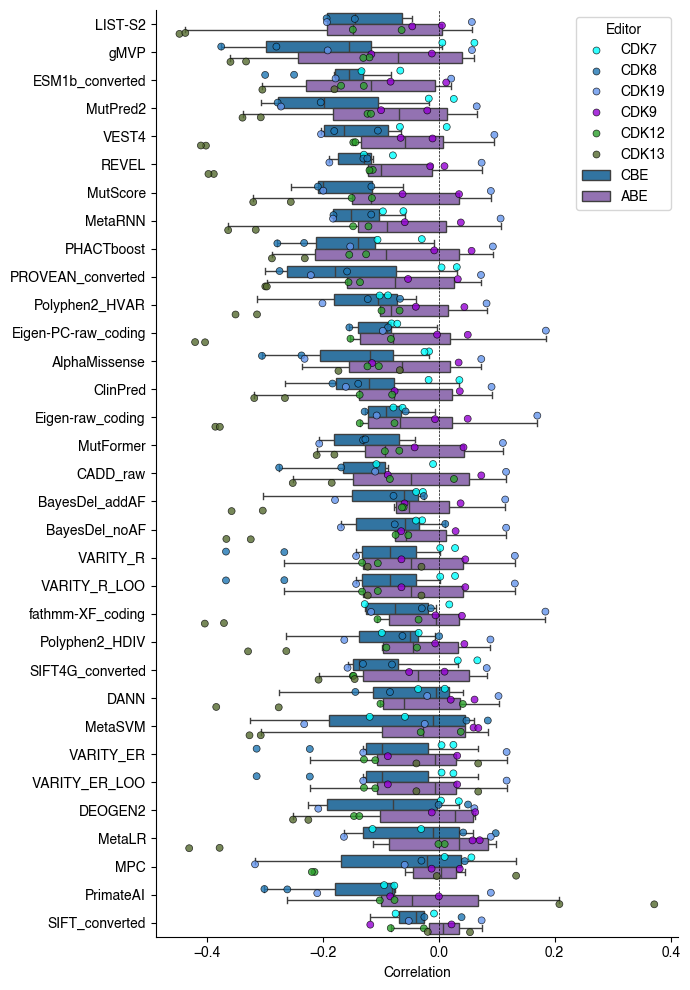

In [544]:
aa = pd.concat(pear_holder).reset_index(drop=True)
aa = aa[~aa['Correlation'].isna()].reset_index(drop=True)

# Step 1: Order VEPs by median or mean Correlation
vep_order = aa.groupby('VEP')['Correlation'].mean().sort_values(ascending=True).index.to_list()
vep_order = [i for i in vep_order if i in veps]
# Step 2: Create the stripplotfig

color_dict = {'CDK7':'cyan', 
              'CDK8':'tab:blue', 
              'CDK19':'cornflowerblue', 
              'CDK9':'darkviolet', 
              'CDK12':'tab:green', 
              'CDK13':'darkolivegreen',}
              #'CDK2':'goldenrod',
              #'CDK4':'tab:red', 
              #'CDK6':'tab:orange',}


fig, ax = plt.subplots(figsize=(7,10))

palette = color_dict.values()
hue_order = color_dict.keys()

sns.stripplot(
    data=aa,
    y='VEP',
    x='Correlation',
    order=vep_order,          # descending order by median
    hue='Gene',               # or 'Editor'
    dodge=True,
    jitter=True,
    size=5,
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5,
    hue_order = hue_order,
    palette=palette
)

sns.boxplot(data=aa,y='VEP', x='Correlation',hue='Editor', order=vep_order, showfliers=False, palette=['tab:blue', 'tab:purple'])

ax.set_yticklabels([i[:-10] for i in vep_order])
ax.axvline(0, linestyle='dashed', color='black', linewidth=0.5)
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylabel('')
fig.tight_layout()

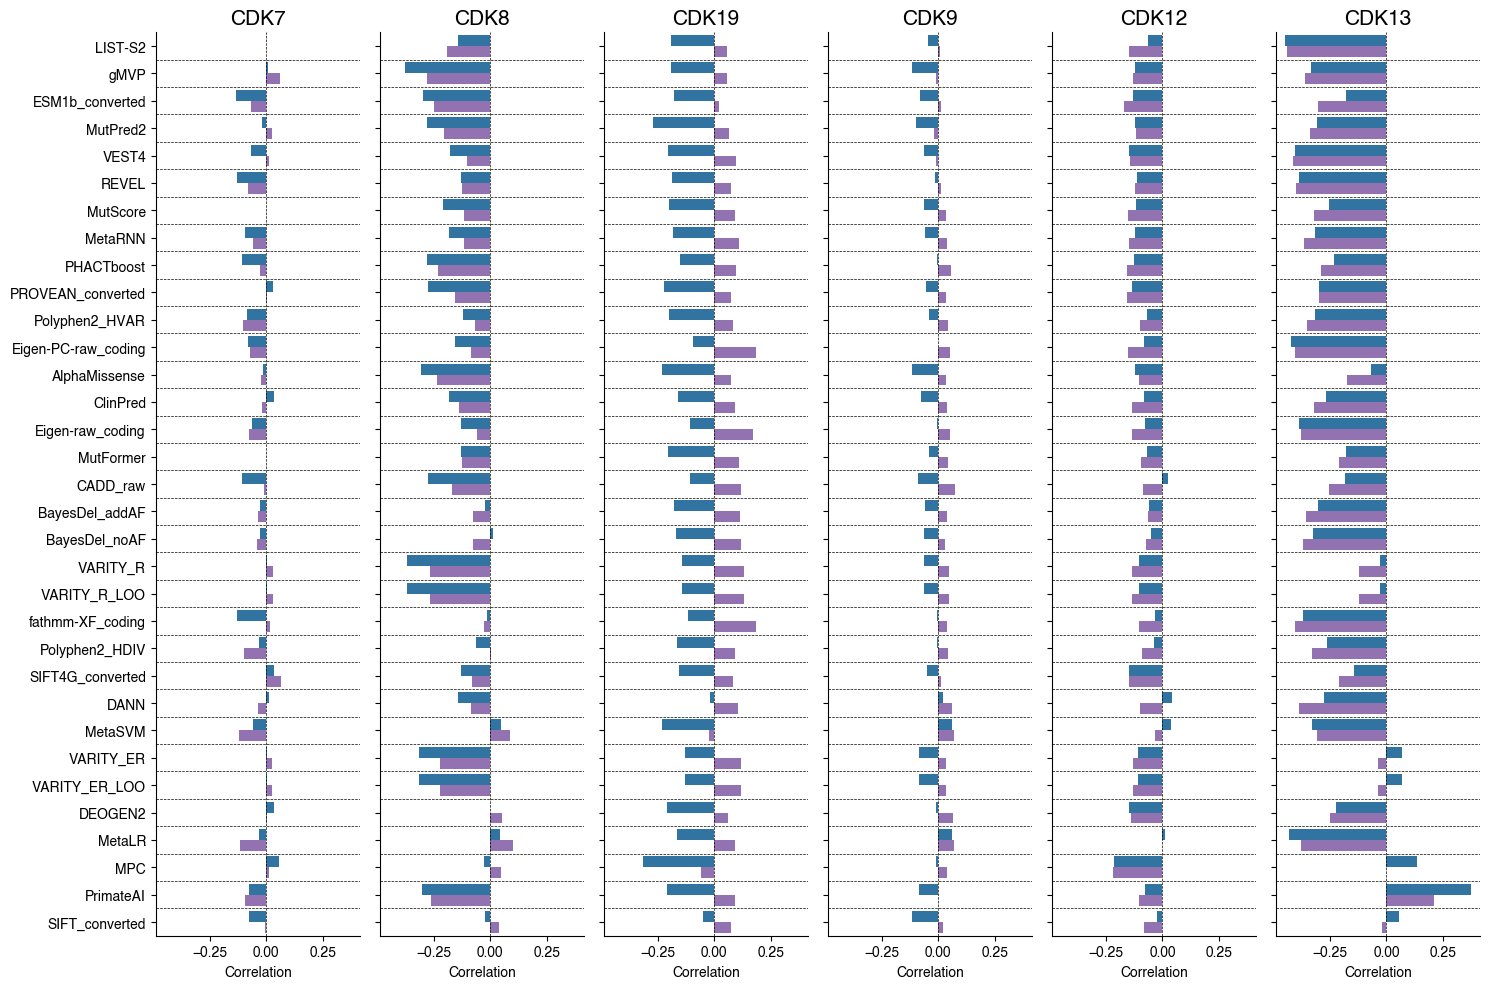

In [545]:
aa = pd.concat(pear_holder).reset_index(drop=True)
aa = aa[~aa['Correlation'].isna()].reset_index(drop=True)

# Step 1: Order VEPs by median or mean Correlation
vep_order = aa.groupby('VEP')['Correlation'].mean().sort_values(ascending=True).index.to_list()
vep_order = [i for i in vep_order if i in veps]
# Step 2: Create the stripplotfig

color_dict = {'CDK7':'cyan', 
              'CDK8':'tab:blue', 
              'CDK19':'cornflowerblue', 
              'CDK9':'darkviolet', 
              'CDK12':'tab:green', 
              'CDK13':'darkolivegreen',}
              #'CDK2':'goldenrod',
              #'CDK4':'tab:red', 
              #'CDK6':'tab:orange',}


fig, ax = plt.subplots(1,6,figsize=(15,10), sharex=True, sharey=True)

palette = list(color_dict.values())
hue_order = list(color_dict.keys())

for i, gene in enumerate(hue_order):


    sns.barplot(data=aa[aa['Gene']==gene],y='VEP', x='Correlation', order=vep_order, ax=ax[i], hue='Editor', palette=['tab:blue', 'tab:purple'], legend=False)#,color=palette[i])

    ax[i].set_yticklabels([j[:-10] for j in vep_order])
    ax[i].axvline(0, linestyle='dashed', color='black', linewidth=0.5)

    for k in range(len(vep_order)):
        ax[i].axhline(k+0.5, linestyle='dashed', color='black', linewidth=0.5)

    ax[i].spines[['top', 'right']].set_visible(False)
    ax[i].set_ylabel('')
    ax[i].set_title(gene, fontsize=15)

fig.tight_layout()

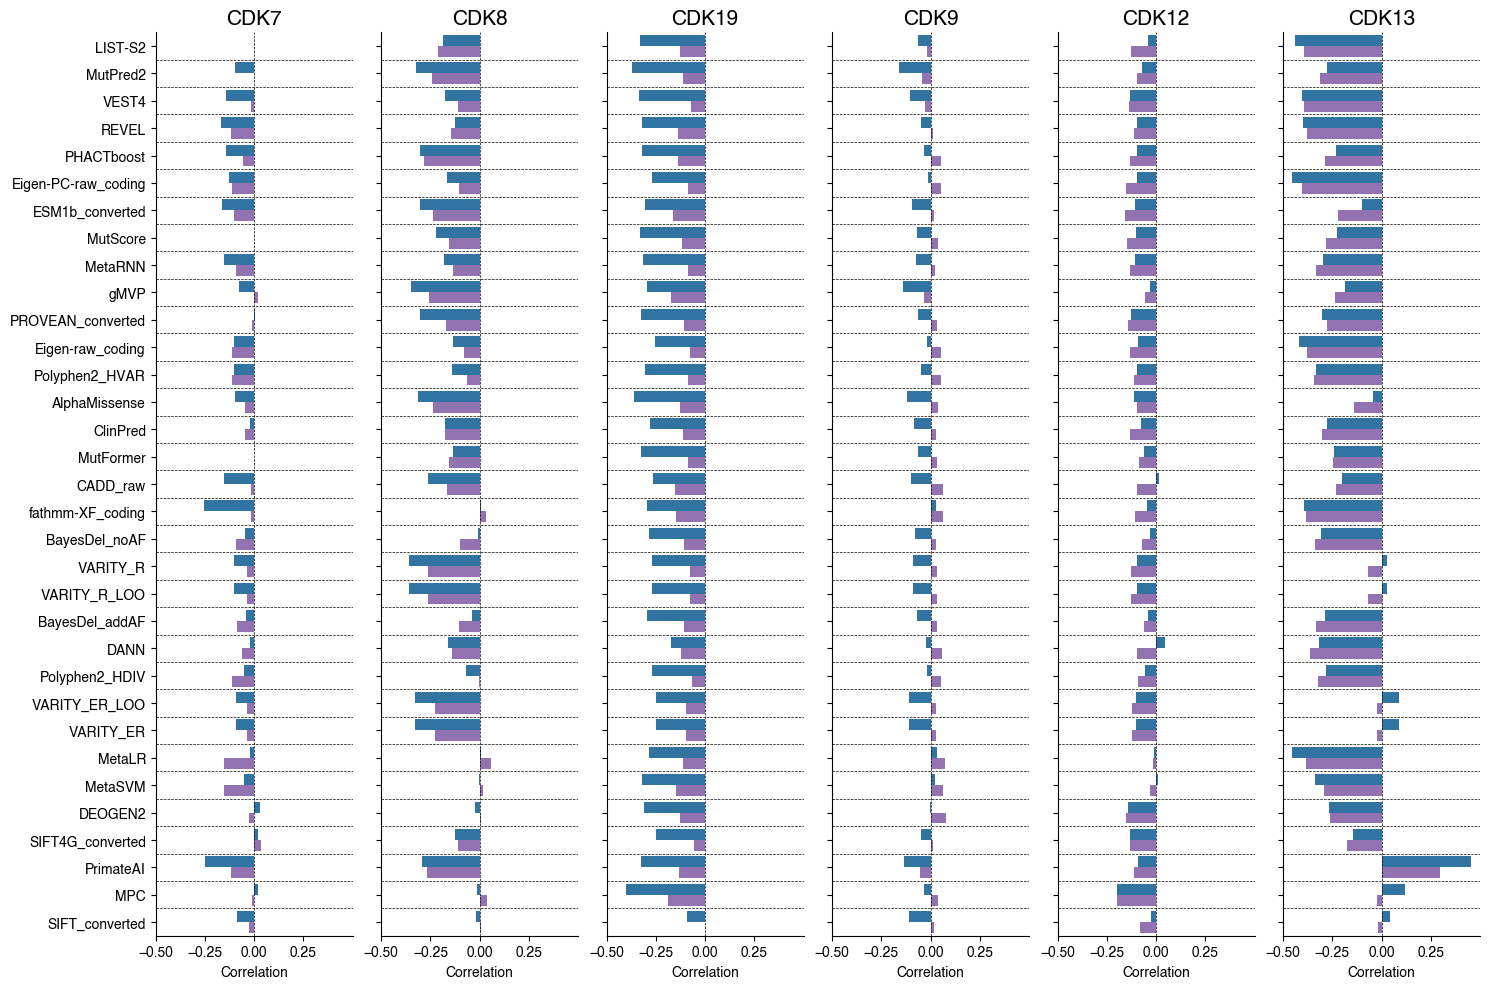

In [546]:
aa = pd.concat(spear_holder).reset_index(drop=True)
aa = aa[~aa['Correlation'].isna()].reset_index(drop=True)

# Step 1: Order VEPs by median or mean Correlation
vep_order = aa.groupby('VEP')['Correlation'].mean().sort_values(ascending=True).index.to_list()
vep_order = [i for i in vep_order if i in veps]
# Step 2: Create the stripplotfig

color_dict = {'CDK7':'cyan', 
              'CDK8':'tab:blue', 
              'CDK19':'cornflowerblue', 
              'CDK9':'darkviolet', 
              'CDK12':'tab:green', 
              'CDK13':'darkolivegreen',}
              #'CDK2':'goldenrod',
              #'CDK4':'tab:red', 
              #'CDK6':'tab:orange',}


fig, ax = plt.subplots(1,6,figsize=(15,10), sharex=True, sharey=True)

palette = list(color_dict.values())
hue_order = list(color_dict.keys())

for i, gene in enumerate(hue_order):


    sns.barplot(data=aa[aa['Gene']==gene],y='VEP', x='Correlation', order=vep_order, ax=ax[i], hue='Editor', palette=['tab:blue', 'tab:purple'], legend=False)#,color=palette[i])

    ax[i].set_yticklabels([j[:-10] for j in vep_order])
    ax[i].axvline(0, linestyle='dashed', color='black', linewidth=0.5)

    for k in range(len(vep_order)):
        ax[i].axhline(k+0.5, linestyle='dashed', color='black', linewidth=0.5)

    ax[i].spines[['top', 'right']].set_visible(False)
    ax[i].set_ylabel('')
    ax[i].set_title(gene, fontsize=15)

fig.tight_layout()

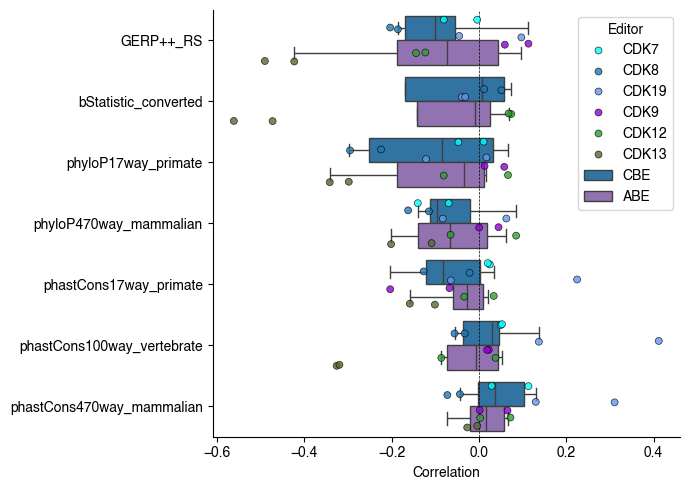

In [533]:
aa = pd.concat(pear_holder).reset_index(drop=True)
aa = aa[~aa['Correlation'].isna()].reset_index(drop=True)

# Step 1: Order VEPs by median or mean Correlation
vep_order = aa.groupby('VEP')['Correlation'].mean().sort_values(ascending=True).index.to_list()
vep_order = [i for i in vep_order if i in cons]
# Step 2: Create the stripplotfig

color_dict = {'CDK7':'cyan', 
              'CDK8':'tab:blue', 
              'CDK19':'cornflowerblue', 
              'CDK9':'darkviolet', 
              'CDK12':'tab:green', 
              'CDK13':'darkolivegreen',}
              #'CDK2':'goldenrod',
              #'CDK4':'tab:red', 
              #'CDK6':'tab:orange',}


fig, ax = plt.subplots(figsize=(7,5))

palette = color_dict.values()
hue_order = color_dict.keys()

sns.stripplot(
    data=aa,
    y='VEP',
    x='Correlation',
    order=vep_order,          # descending order by median
    hue='Gene',               # or 'Editor'
    dodge=True,
    jitter=True,
    size=5,
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5,
    hue_order = hue_order,
    palette=palette
)

sns.boxplot(data=aa,y='VEP', x='Correlation',hue='Editor', order=vep_order, showfliers=False, palette=['tab:blue', 'tab:purple'])

ax.set_yticklabels([i[:-10] for i in vep_order])
ax.axvline(0, linestyle='dashed', color='black', linewidth=0.5)
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylabel('')
fig.tight_layout()

In [ ]:
vep_order = aa.groupby('VEP')['Correlation'].mean().sort_values(ascending=True).index.to_list()

RS = [i for i in vep_order if ('_rankscore' or 'RS') in i]

len(RS)

cons = ['GERP++_RS_rankscore',
        'GERP++_NR'
        'phyloP100way_vertebrate_rankscore',
        'phyloP17way_primate_rankscore',
        'phyloP470way_mammalian_rankscore',
        'phastCons17way_primate_rankscore',
        'phastCons470way_mammalian_rankscore',
        'phastCons100way_vertebrate_rankscore',
        'bStatistic_converted_rankscore',
        ]

veps = ['LIST-S2_rankscore',
 'gMVP_rankscore',
 'ESM1b_converted_rankscore',
 'MutPred2_rankscore',
 'VEST4_rankscore',
 'REVEL_rankscore',
 'MutScore_rankscore',
 'MetaRNN_rankscore',
 'PHACTboost_rankscore',
 'PROVEAN_converted_rankscore',
 'Polyphen2_HVAR_rankscore',
 'Eigen-PC-raw_coding_rankscore',
 'AlphaMissense_rankscore',
 'ClinPred_rankscore',
 'Eigen-raw_coding_rankscore',
 'MutFormer_rankscore',
 'CADD_raw_rankscore',
 'BayesDel_addAF_rankscore',
 'BayesDel_noAF_rankscore',
 'VARITY_R_rankscore',
 'VARITY_R_LOO_rankscore',
 'fathmm-XF_coding_rankscore',
 'Polyphen2_HDIV_rankscore',
 'SIFT4G_converted_rankscore',
 'DANN_rankscore',
 'MetaSVM_rankscore',
 'VARITY_ER_rankscore',
 'VARITY_ER_LOO_rankscore',
 'DEOGEN2_rankscore',
 'MetaLR_rankscore',
 'MPC_rankscore',
 'PrimateAI_rankscore',
 'MVP_rankscore',
 'SIFT_converted_rankscore',
 'M-CAP_rankscore',
 'MutationAssessor_rankscore',
 ]




36

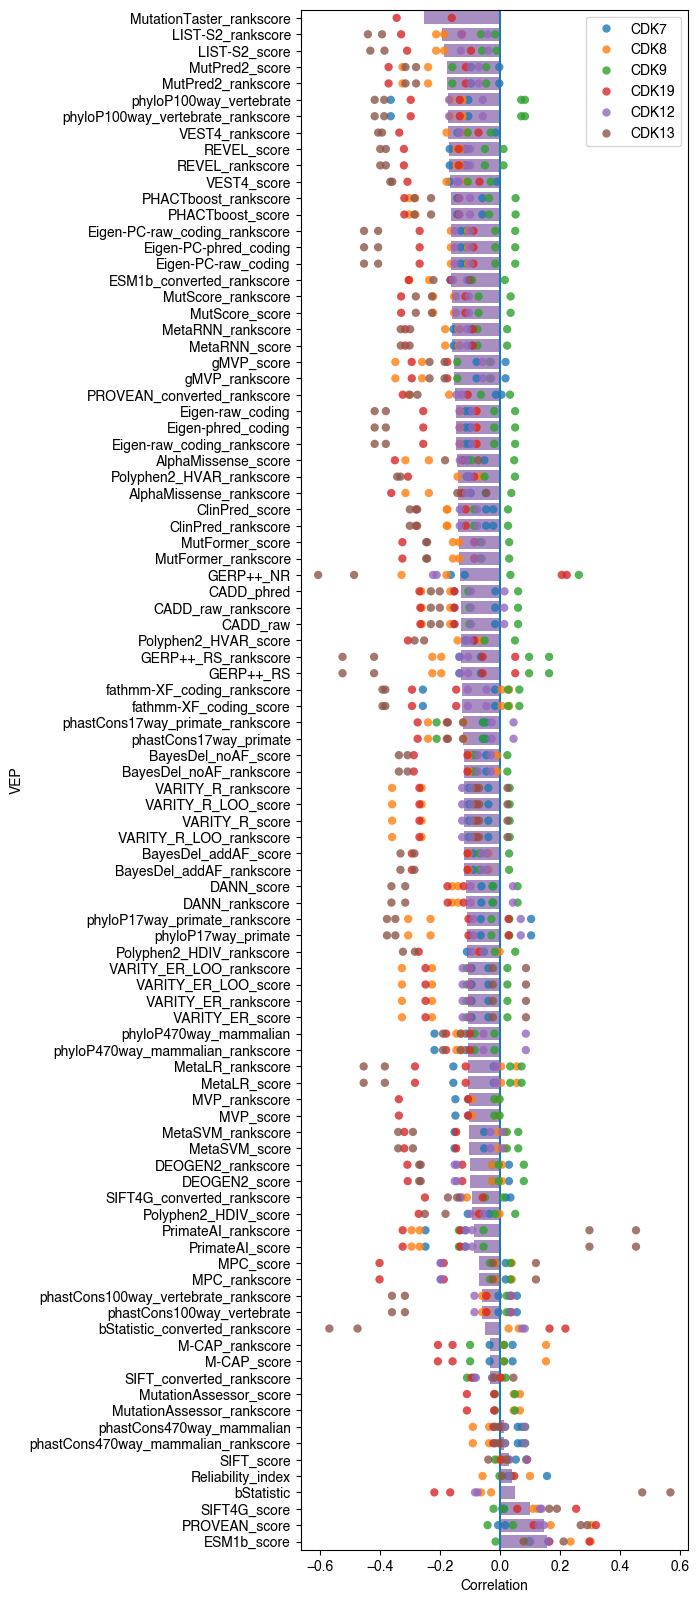

In [425]:
aa = pd.concat(spear_holder).reset_index(drop=True)
aa = aa[~aa['Correlation'].isna()].reset_index(drop=True)

# Step 1: Order VEPs by median or mean Correlation
vep_order = aa.groupby('VEP')['Correlation'].mean().sort_values(ascending=True).index.to_list()

# Step 2: Create the stripplotfig

fig, ax = plt.subplots(figsize=(5,20))

sns.stripplot(
    data=aa,
    y='VEP',
    x='Correlation',
    order=vep_order,          # descending order by median
    hue='Gene',               # or 'Editor'
    dodge=False,
    jitter=False,
    size=6,
    alpha=0.8
)

sns.barplot(
    data=aa,
    y='VEP',
    x='Correlation',
    order=vep_order,          # descending order by median             # or 'Editor'
    alpha=0.8,
    errorbar=None
)
ax.axvline(0)

<Axes: xlabel='Gene', ylabel='Correlation'>

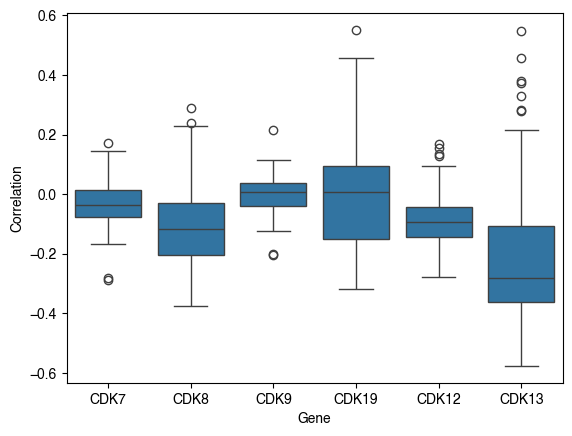

In [417]:
sns.boxplot(data=aa, x='Gene', y='Correlation')

<Axes: xlabel='value', ylabel='VEP'>

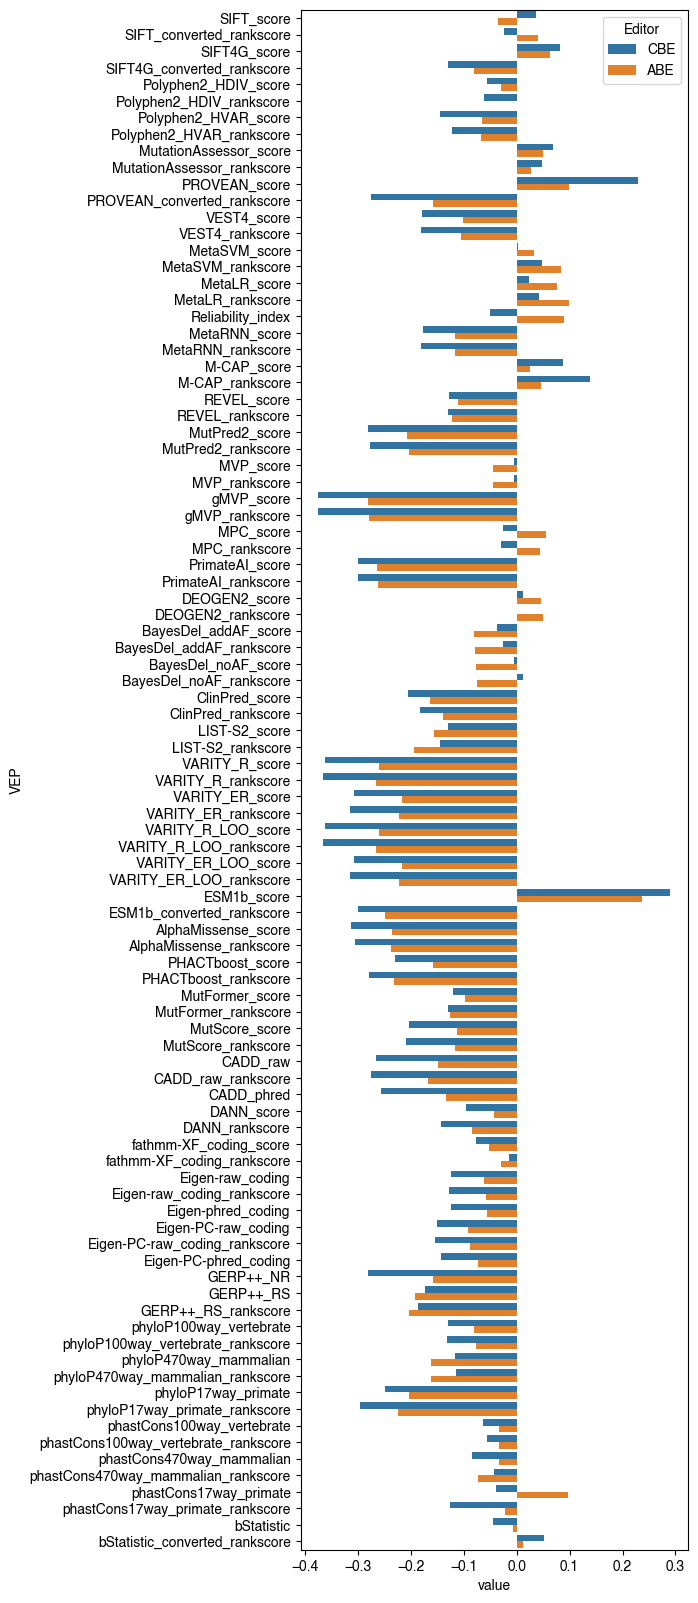

In [365]:
fig, ax = plt.subplots(figsize=(5,20))
sns.barplot(data=pear.melt(id_vars = ('VEP','Gene', 'Editor')).reset_index(), y='VEP', x='value', hue='Editor')

In [333]:

abe_pear_list = []
abe_spear_list = []
cbe_pear_list = []
cbe_spear_list = []
vep_name = []

for i in comb_VEP_cons:
    
    try:
        cbe_spear = scipy.stats.spearmanr([float(i) for i in merge_cbe[i]], merge_cbe['LFC_median_T0']).statistic
        cbe_pear = scipy.stats.pearsonr([float(i) for i in merge_cbe[i]], merge_cbe['LFC_median_T0']).statistic

        abe_spear = scipy.stats.spearmanr([float(i) for i in merge_abe[i]], merge_abe['LFC_median_T0']).statistic
        abe_pear = scipy.stats.pearsonr([float(i) for i in merge_abe[i]], merge_abe['LFC_median_T0']).statistic

        vep_name.append(i)
        abe_pear_list.append(abe_pear)
        abe_spear_list.append(abe_spear)
        cbe_pear_list.append(cbe_pear)
        cbe_spear_list.append(cbe_spear)
        
    except:
        continue

In [334]:
CBE_pear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), cbe_pear_list,vep_name])))
ABE_pear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), abe_pear_list,vep_name])))
CBE_spear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), cbe_spear_list,vep_name])))
ABE_spear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), abe_spear_list,vep_name])))

CBE_pear_df['Editor']='CBE'
ABE_pear_df['Editor']='ABE'
CBE_spear_df['Editor']='CBE'
ABE_spear_df['Editor']='ABE'

spearman_df = pd.concat((CBE_spear_df, ABE_spear_df))
pearson_df = pd.concat((CBE_pear_df, ABE_pear_df))

In [335]:
spearman_df.sort_values(by='Correlation')[:20]

,Gene,Correlation,VEP,Editor
70,CDK12,-0.223117,GERP++_NR,CBE
70,CDK12,-0.211102,GERP++_NR,ABE
26,CDK12,-0.197999,MPC_rankscore,ABE
25,CDK12,-0.197994,MPC_score,ABE
25,CDK12,-0.196669,MPC_score,CBE
26,CDK12,-0.196652,MPC_rankscore,CBE
73,CDK12,-0.169242,phyloP100way_vertebrate,ABE
74,CDK12,-0.169242,phyloP100way_vertebrate_rankscore,ABE
48,CDK12,-0.156160,ESM1b_converted_rankscore,ABE
68,CDK12,-0.151024,Eigen-PC-raw_coding_rankscore,ABE


# Disorder analysis

In [457]:
d = '../../source_data/20_metapredict_disorder'

genes = ['CDK7', 'CDK8', 'CDK9', 'CDK19', 'CDK12', 'CDK13']

d_list = []
for gene in genes:
    disorder = pd.read_csv(f'{d}/{gene}_disorder_scores.csv').rename(columns = {' Index':'Codon'})
    disorder['Codon'] = [str(i) for i in disorder['Codon']]
    d_list.append(disorder)
disorder_dict = dict(zip(genes, d_list))

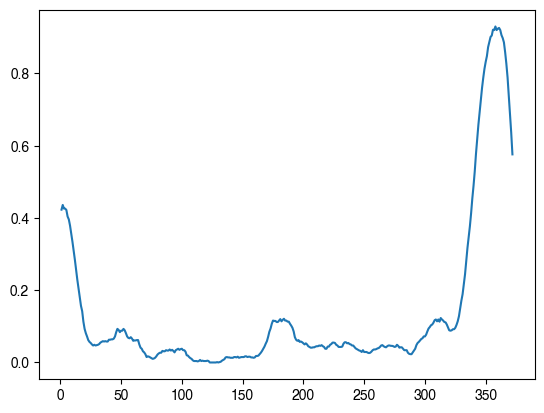

In [480]:
d = disorder_dict['CDK9']
plt.plot([int(i) for i in d['Codon']], d[' Disorder'])

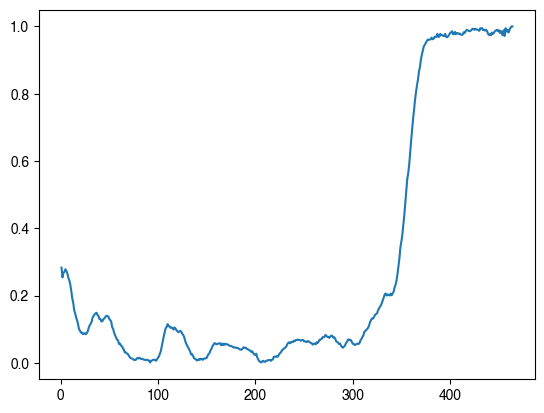

In [485]:
d = disorder_dict['CDK8']
plt.plot([int(i) for i in d['Codon']], d[' Disorder'])

In [ ]:
def corr_disorder(gene, min_edit, min_base_counts):
    edits = sav_dict[gene].rename(columns = {'HGVSp_new':'HGVSp_VEP'})

    mis = edits[edits['Var_Type']=='Missense']

    mis_abe = mis[mis['Editor']=='ABE'].reset_index(drop=True)
    mis_cbe = mis[mis['Editor']=='CBE'].reset_index(drop=True)

    if gene in ['CDK7', 'CDK8', 'CDK9', 'CDK19']:
        lfc_info_abe = ABE1[ABE1['base_RAW']>=min_base_counts][['gRNA_id', 'LFC_median_T0']]
        lfc_info_cbe = CBE1[CBE1['base_RAW']>=min_base_counts][['gRNA_id', 'LFC_median_T0']]
    elif gene in ['CDK12', 'CDK13']:
        lfc_info_abe = ABE2[ABE2['base_RAW']>=min_base_counts][['gRNA_id', 'LFC_median_ABE_T0']].rename(columns = {'LFC_median_ABE_T0':'LFC_median_T0'})
        lfc_info_cbe = CBE2[CBE2['base_RAW']>=min_base_counts][['gRNA_id', 'LFC_median_CBE_T0']].rename(columns = {'LFC_median_CBE_T0':'LFC_median_T0'})

    merge_cbe = pd.merge(mis_cbe, lfc_info_cbe, on='gRNA_id')
    merge_abe = pd.merge(mis_abe, lfc_info_abe, on='gRNA_id')


    merge_cbe = merge_cbe[merge_cbe['%Reads']>=min_edit]
    merge_abe = merge_abe[merge_abe['%Reads']>=min_edit]

    dis1 = disorder_dict[gene]

    merge_cbe2 = pd.merge(merge_cbe, dis1, on='Codon')
    merge_abe2 = pd.merge(merge_abe, dis1, on='Codon')


    abe_pear_list = []
    abe_spear_list = []
    cbe_pear_list = []
    cbe_spear_list = []
    vep_name = []


    i = ' Disorder'
    cbe_spear = scipy.stats.spearmanr([float(i) for i in merge_cbe2[i]], merge_cbe2['LFC_median_T0']).statistic
    cbe_pear = scipy.stats.pearsonr([float(i) for i in merge_cbe2[i]], merge_cbe2['LFC_median_T0']).statistic

    abe_spear = scipy.stats.spearmanr([float(i) for i in merge_abe2[i]], merge_abe2['LFC_median_T0']).statistic
    abe_pear = scipy.stats.pearsonr([float(i) for i in merge_abe2[i]], merge_abe2['LFC_median_T0']).statistic

    vep_name.append(i)
    abe_pear_list.append(abe_pear)
    abe_spear_list.append(abe_spear)
    cbe_pear_list.append(cbe_pear)
    cbe_spear_list.append(cbe_spear)
            

    CBE_pear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), cbe_pear_list,vep_name])))
    ABE_pear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), abe_pear_list,vep_name])))
    CBE_spear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), cbe_spear_list,vep_name])))
    ABE_spear_df = pd.DataFrame(dict(zip(['Gene', 'Correlation', 'VEP'], [[gene]*len(vep_name), abe_spear_list,vep_name])))

    CBE_pear_df['Editor']='CBE'
    ABE_pear_df['Editor']='ABE'
    CBE_spear_df['Editor']='CBE'
    ABE_spear_df['Editor']='ABE'

    spearman_df = pd.concat((CBE_spear_df, ABE_spear_df))
    pearson_df = pd.concat((CBE_pear_df, ABE_pear_df))

    return spearman_df, pearson_df



In [552]:

genes = ['CDK7', 'CDK8', 'CDK9', 'CDK19', 'CDK12', 'CDK13']
gene = 'CDK19'
min_edit = 20
min_base_counts = 100

pear_holder2 = []
spear_holder2 = []
for gene in genes:
    spearman_df, pearson_df = corr_disorder(gene, min_edit, min_base_counts)
    pear_holder2.append(pearson_df)
    spear_holder2.append(spearman_df)



Text(0.5, 1.0, 'Disorder vs. T0-plasmid')

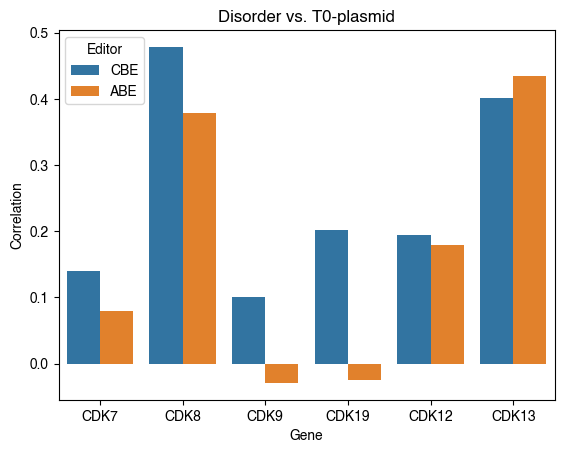

In [561]:
aaa = pd.concat(pear_holder2).reset_index(drop=True)

sns.barplot(data=aaa, x='Gene', y='Correlation', hue='Editor')

plt.title('Disorder vs. T0-plasmid')

In [559]:
aaa

,Gene,Correlation,VEP,Editor
0,CDK7,0.139193,Disorder,CBE
1,CDK7,0.078908,Disorder,ABE
2,CDK8,0.478578,Disorder,CBE
3,CDK8,0.378898,Disorder,ABE
4,CDK9,0.101097,Disorder,CBE
5,CDK9,-0.029198,Disorder,ABE
6,CDK19,0.201391,Disorder,CBE
7,CDK19,-0.025205,Disorder,ABE
8,CDK12,0.193616,Disorder,CBE
9,CDK12,0.179691,Disorder,ABE


In [ ]:
scipy.stats.pearsonr(merge_cbe2['LFC_median_T0'], merge_cbe2[' Disorder']).s

PearsonRResult(statistic=0.20139081983131657, pvalue=2.151727565901353e-07)